# import libraries

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# helps load dataset
from datasets import load_dataset

# load dataset

In [32]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [33]:
label_names = emotion_dataset['train'].features['label'].names

In [34]:
df_train = pd.DataFrame(
    {
        'text' : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text': test_text,
        'label': [label_names[i] for i in test_label]
    }
)

In [35]:
df_train.isnull().sum()

,0
text,0
label,0


# exploratory data analysis

<Axes: xlabel='label', ylabel='count'>

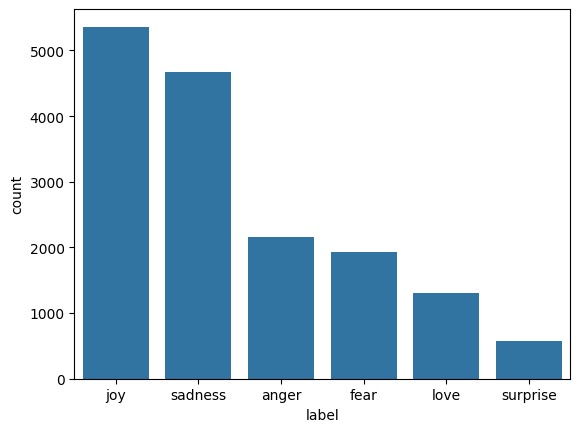

In [36]:
sns.countplot(x = 'label', data = df_train, order = df_train['label'].value_counts().index)

# Data processing - NLP

In [37]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words = max_words, oov_token = '<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence, maxlen=50, padding = 'post', truncating = 'post')
padded_test_sequence = pad_sequences(test_sequence, maxlen=50, padding='post', truncating = 'post')

train_labels = np.array(train_label)
test_labels = np.array(test_label)


num_classes = len(np.unique(train_labels))

print(f"Vocablury Size: {len(tokenizer.word_index)}")
print(f"Meax Sentence Length: {padded_train_sequence.shape[1]}")

Vocablury Size: 15213
Meax Sentence Length: 50


# shared training utilities

In [38]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)
class_weight_dict= dict(enumerate(class_weights))

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights=True
)

# Model 1 - Simple RNN

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation = 'softmax')
])

rnn_model.compile(optimizer = 'adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [41]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f'RNN Loss: {rnn_loss}')
print(f'RNN Accuracy: {rnn_accuracy}')

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.1548 - loss: 2.0347 - val_accuracy: 0.0410 - val_loss: 1.8282
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.1477 - loss: 1.8781 - val_accuracy: 0.1050 - val_loss: 1.8061
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.1248 - loss: 1.8287 - val_accuracy: 0.0785 - val_loss: 1.8333
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.1241 - loss: 1.8093 - val_accuracy: 0.0355 - val_loss: 1.8097
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.1312 - loss: 1.8036 - val_accuracy: 0.0875 - val_loss: 1.7798
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.1414 - loss: 1.8028 - val_accuracy: 0.3255 - val_loss: 1.7777
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.1455 - loss: 1.8010 - val_accuracy: 0.2530 - val_loss: 1.8033
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.1427 - loss: 1.8010 - 

# Model 2 - Standard LSTM

In [42]:
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [46]:
lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f'LSTM loss: {lstm_loss}')
print(f'LSTM accuracy: {lstm_accuracy}')

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 80ms/step - accuracy: 0.1584 - loss: 1.7940 - val_accuracy: 0.0805 - val_loss: 1.7992
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.1338 - loss: 1.7934 - val_accuracy: 0.0330 - val_loss: 1.7991
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 80ms/step - accuracy: 0.1179 - loss: 1.7929 - val_accuracy: 0.0335 - val_loss: 1.8011
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0805 - loss: 1.7992
LSTM loss: 1.79915452003479
LSTM accuracy: 0.08049999922513962


# Model 3 - Standard GRU

In [44]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim=128, input_length=50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [45]:
gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f'GRU Loss: {gru_loss}')
print(f'GRU Accuracy: {gru_accuracy}')

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 63ms/step - accuracy: 0.1447 - loss: 1.7968 - val_accuracy: 0.0365 - val_loss: 1.7983
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1459 - loss: 1.7946 - val_accuracy: 0.1375 - val_loss: 1.8165
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.1502 - loss: 1.7953 - val_accuracy: 0.1380 - val_loss: 1.7895
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0365 - loss: 1.7983
GRU Loss: 1.7983407974243164
GRU Accuracy: 0.0364999994635582


In [51]:
result_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Test Accuracy', ascending=False)
result_df

,Model,Test Loss,Test Accuracy
0,RNN,1.752077,0.0825
1,LSTM,1.799155,0.0805
2,GRU,1.798341,0.0365


# Advanced Bidirectional GRU

In [55]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300, input_length=50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(units = num_classes, activation='softmax')
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
BiGRU.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [61]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data = [padded_test_sequence, test_labels],
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stopping]
)

BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f'BIGRU loss: {bigru_loss}')
print(f'BIGRU accuracy: {bigru_accuracy}')

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 97s 194ms/step - accuracy: 0.9573 - loss: 0.1145 - val_accuracy: 0.9200 - val_loss: 0.2605
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 98s 196ms/step - accuracy: 0.9680 - loss: 0.0884 - val_accuracy: 0.9275 - val_loss: 0.2395
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 170s 252ms/step - accuracy: 0.9736 - loss: 0.0710 - val_accuracy: 0.9250 - val_loss: 0.2606
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9200 - loss: 0.2605
BIGRU loss: 0.18262837827205658
BIGRU accuracy: 0.9235000014305115


# Advanced Bidirectional LSTM

In [58]:
from tensorflow.keras.layers import Bidirectional

BiLSTM = Sequential([
    Embedding(input_dim=max_words, output_dim = 300, input_length=50),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    Dropout(0>5),
    Dense(units= num_classes, activation='softmax')
])

BiLSTM.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [60]:
BiLSTM.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks=[early_stopping]
)

BiLSTM_loss, BiLSTM_accuracy = BiLSTM.evaluate(padded_test_sequence, test_labels)
print(f'BiLSTM Loss: {BiLSTM_loss}')
print(f'BiLSTM Accuracy: {BiLSTM_accuracy}')

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 153s 292ms/step - accuracy: 0.6454 - loss: 0.9200 - val_accuracy: 0.8855 - val_loss: 0.3523
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 137s 274ms/step - accuracy: 0.9178 - loss: 0.2205 - val_accuracy: 0.9050 - val_loss: 0.2623
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 267ms/step - accuracy: 0.9373 - loss: 0.1547 - val_accuracy: 0.9115 - val_loss: 0.2258
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8855 - loss: 0.3523
BiLSTM Loss: 0.35229045152664185
BiLSTM Accuracy: 0.8855000138282776


# Overall Evaluation and Bias Analysis

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step


<Axes: >

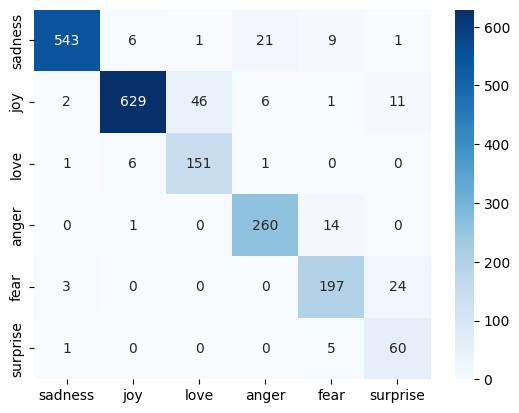

In [71]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence), axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions), annot=True, fmt='d', cmap='Blues', xticklabels = label_names, yticklabels=label_names)

# final sample predictions

In [73]:
sample_texts= [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shoked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Sentiment: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Sentiment: surprise
Text: I feel so alone and hopeless today.
Predicted Sentiment: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Sentiment: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Sentiment: fear
Text: I was shoked and completely surprised by the unexpected gift!
Predicted Sentiment: surprise


Save Model and Tokenizer

In [76]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) # creates a empty folder to store exported files

#Save the BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Model.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer,file)